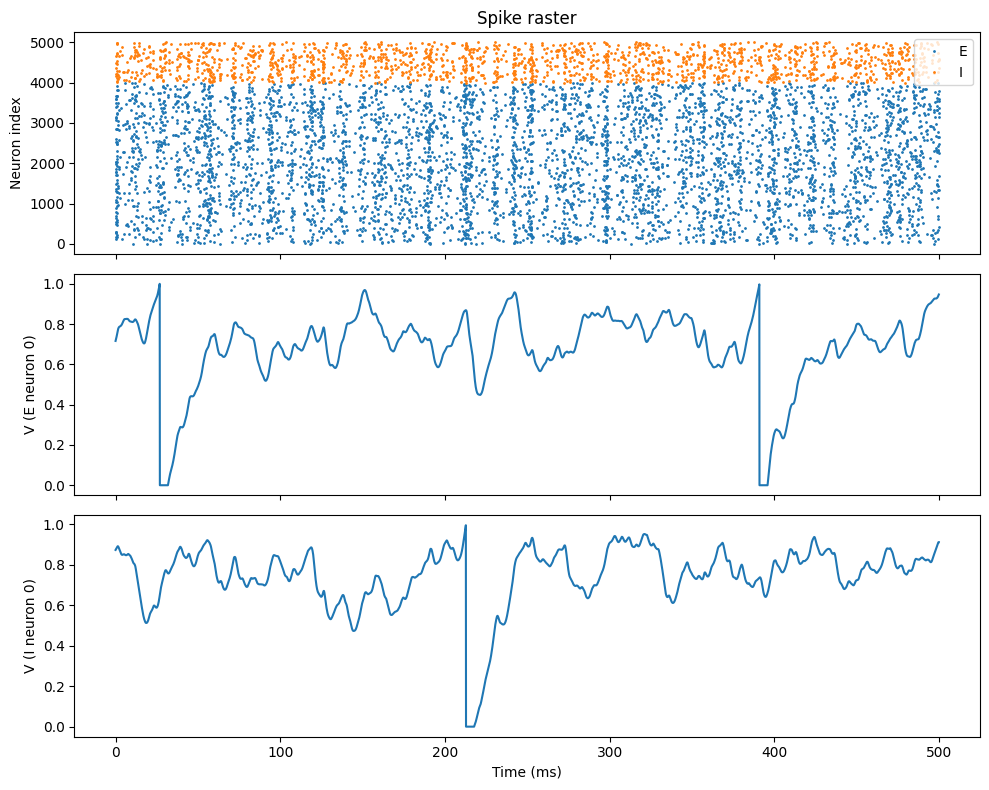

In [ ]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# --- Network parameters ---
rng = np.random.default_rng(seed=42)

N_E = 4000  # number of excitatory neurons
N_I = 1000  # number of inhibitory neurons
N_ref = 5000  # reference network size (for weight scaling)

def scale_weights(j_ee, j_ei, j_ie, j_ii, N_total, N_ref=5000):
    """
    Scale synaptic weights based on network size.
    
    Weights scale as 1/sqrt(N) to maintain constant variance 
    of total synaptic input as network size changes.

    tuple : scaled (j_ee, j_ei, j_ie, j_ii)
    """
    scale_factor = np.sqrt(N_ref / N_total)
    return (
        j_ee * scale_factor,
        j_ei * scale_factor,
        j_ie * scale_factor,
        j_ii * scale_factor
    )

# Neuron parameters
refractory_t = 5*ms # Refractory Period
tau_e = 15*ms  # Membrane Time Constant for E neurons
tau_i = 10*ms  # Membrane Time Constant for I neurons
Vt = 1 # Spike Threshold
Vr = 0 # Reset Potential

# Synaptic time constants
t1 = 1*ms
t2_e = 3*ms # Excitatory synaptic time constant
t2_i = 2*ms # Inhibitory synaptic time constant (faster)


timestep = 0.1*ms

# Reference synaptic weights (from paper, calibrated for N=5000)
j_ee_ref = 0.024   # E -> E
j_ei_ref = 0.014   # E -> I
j_ie_ref = -0.045  # I -> E (negative for inhibition)
j_ii_ref = -0.057  # I -> I

# Scale weights for current network size
j_ee, j_ei, j_ie, j_ii = scale_weights(
    j_ee_ref, j_ei_ref, j_ie_ref, j_ii_ref, 
    N_E + N_I, N_ref
)

# Connection probability
p_conn_e = 0.2
p_conn_i = 0.5 # Connection probability to and from inhibitory populations

eqs = """
dV/dt = (mu - V) / tau + Isyn_e + Isyn_i : 1 (unless refractory)
Isyn_e = g_e * j_e : 1/second
Isyn_i = g_i * j_i : 1/second

dg_e/dt = (x_e - g_e) / t2_e : 1/second
dx_e/dt = -x_e / t1 : 1/second

dg_i/dt = (x_i - g_i) / t2_i : 1/second
dx_i/dt = -x_i / t1 : 1/second

mu : 1      # per-neuron bias (external input)
tau : second  # per-neuron membrane time constant
j_e : 1     # excitatory weight
j_i : 1     # inhibitory weight
"""

# Excitatory population
E = NeuronGroup(
    N_E,
    eqs,
    threshold='V > Vt',
    reset='V = Vr',
    refractory=refractory_t,
    method='euler',
    dt=timestep
)
E.mu = rng.uniform(1.1, 1.2, size=N_E)  # per-neuron bias
E.tau = tau_e  # membrane time constant for E neurons
E.V = rng.uniform(Vr, Vt, size=N_E)  # random initial conditions
E.j_e = j_ee
E.j_i = j_ie

# Inhibitory population
I = NeuronGroup(
    N_I,
    eqs,
    threshold='V > Vt',
    reset='V = Vr',
    refractory=refractory_t,
    method='euler',
    dt=timestep
)
I.mu = rng.uniform(1.0, 1.05, size=N_I)  # per-neuron bias
I.tau = tau_i  # membrane time constant for I neurons
I.V = rng.uniform(Vr, Vt, size=N_I)  # random initial conditions
I.j_e = j_ei
I.j_i = j_ii

# E -> E
S_ee = Synapses(E, E, on_pre='x_e_post += 1/t1', dt=timestep)
S_ee.connect(p=p_conn_e)

# E -> I
S_ei = Synapses(E, I, on_pre='x_e_post += 1/t1', dt=timestep)
S_ei.connect(p=p_conn_i)

# I -> E
S_ie = Synapses(I, E, on_pre='x_i_post += 1/t1', dt=timestep)
S_ie.connect(p=p_conn_i)

# I -> I
S_ii = Synapses(I, I, on_pre='x_i_post += 1/t1', dt=timestep)
S_ii.connect(p=p_conn_i)

# --- External input to kick-start activity ---
# Send a spike to a few E neurons at random times
n_input = 10
indices = np.arange(n_input)
times = rng.uniform(1, 100, size=n_input) * ms  # random times between 1-10 ms
inp = SpikeGeneratorGroup(n_input, indices, times, dt=timestep)

S_inp = Synapses(inp, E[:n_input], on_pre='x_e_post += 1/t1', dt=timestep)
S_inp.connect(j='i')  # one-to-one

# --- Monitors ---
M_E = StateMonitor(E, variables=['V'], record=True)
M_I = StateMonitor(I, variables=['V'], record=True)
spk_E = SpikeMonitor(E)
spk_I = SpikeMonitor(I)

run(500*ms)

# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Raster plot
axes[0].plot(spk_E.t/ms, spk_E.i, '.', markersize=2, label='E')
axes[0].plot(spk_I.t/ms, spk_I.i + N_E, '.', markersize=2, label='I')
axes[0].set_ylabel('Neuron index')
axes[0].set_title('Spike raster')
axes[0].legend(loc='upper right')

# Example E neuron voltage
axes[1].plot(M_E.t/ms, M_E.V[0])
axes[1].set_ylabel('V (E neuron 0)')

# Example I neuron voltage
axes[2].plot(M_I.t/ms, M_I.V[0])
axes[2].set_ylabel('V (I neuron 0)')
axes[2].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()
